In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from urllib.request import Request, urlopen

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
url = 'https://ourworldindata.org/grapher/share-people-fully-vaccinated-covid.csv'
request = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urlopen(request, timeout=90) as response:
    raw_data = response.read()

raw_df = pd.read_csv(BytesIO(raw_data))
raw_df.head()

,Entity,Code,Day,Share of people with a complete initial protocol
0,Afghanistan,AFG,2021-05-11,0.137076
1,Afghanistan,AFG,2021-05-20,0.191134
2,Afghanistan,AFG,2021-05-24,0.238819
3,Afghanistan,AFG,2021-05-26,0.273744
4,Afghanistan,AFG,2021-05-27,0.280291


In [3]:
print('Shape of Dataset:', raw_df.shape)
raw_df.info()

Shape of Dataset: (77011, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77011 entries, 0 to 77010
Data columns (total 4 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Entity                                            77011 non-null  object 
 1   Code                                              77011 non-null  object 
 2   Day                                               77011 non-null  object 
 3   Share of people with a complete initial protocol  77011 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.4+ MB


In [4]:
raw_df.describe(include='all')

,Entity,Code,Day,Share of people with a complete initial protocol
count,77011,77011,77011,77011.000000
unique,227,227,1350,NaN
top,Oceania,OWID_OCE,2021-08-09,NaN
freq,1350,1350,129,NaN
mean,NaN,NaN,NaN,47.264373
std,NaN,NaN,NaN,29.109145
min,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,19.478954
50%,NaN,NaN,NaN,56.594050
75%,NaN,NaN,NaN,73.060310


In [5]:
countries = ['India', 'United States', 'Brazil', 'Japan']

df = raw_df.rename(columns={
    'Entity': 'country',
    'Code': 'code',
    'Day': 'date',
    'Share of people with a complete initial protocol': 'vaccinated_pct'
})

df['date'] = pd.to_datetime(df['date'])
df = df[df['country'].isin(countries)].copy()
df = df.sort_values(['country', 'date'])

country_summary = df.groupby('country').agg(
    records=('vaccinated_pct', 'size'),
    first_date=('date', 'min'),
    last_date=('date', 'max')
).reset_index()

country_summary

,country,records,first_date,last_date
0,Brazil,694,2021-01-17,2023-03-22
1,India,1238,2021-01-15,2024-08-12
2,Japan,794,2021-02-17,2023-12-31
3,United States,878,2020-12-13,2023-05-09


In [6]:
print('Shape After Country Selection:', df.shape)
df.info()

Shape After Country Selection: (3604, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 3604 entries, 9884 to 72364
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   country         3604 non-null   object        
 1   code            3604 non-null   object        
 2   date            3604 non-null   datetime64[ns]
 3   vaccinated_pct  3604 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 140.8+ KB


In [7]:
df.isnull().sum()

country           0
code              0
date              0
vaccinated_pct    0
dtype: int64

In [8]:
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


In [9]:
rows_before = len(df)
duplicates_before = df.duplicated().sum()

df_clean = df.drop_duplicates().copy()
df_clean['vaccinated_pct'] = df_clean.groupby('country')['vaccinated_pct'].ffill()
df_clean['vaccinated_pct'] = df_clean.groupby('country')['vaccinated_pct'].bfill()
df_clean['vaccinated_pct'] = df_clean['vaccinated_pct'].clip(0, 100)

rows_after = len(df_clean)
duplicates_after = df_clean.duplicated().sum()
missing_after = df_clean.isnull().sum().sum()

cleaning_summary = pd.DataFrame({
    'Step': ['Rows Before Cleaning', 'Duplicate Rows Before', 'Rows After Cleaning', 'Duplicate Rows After', 'Missing Values After Cleaning'],
    'Output': [rows_before, duplicates_before, rows_after, duplicates_after, missing_after]
})

cleaning_summary

,Step,Output
0,Rows Before Cleaning,3604
1,Duplicate Rows Before,0
2,Rows After Cleaning,3604
3,Duplicate Rows After,0
4,Missing Values After Cleaning,0


In [10]:
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.month_name().str[:3]
df_clean['days_since_start'] = (df_clean['date'] - df_clean['date'].min()).dt.days

df_clean.groupby('country').tail(2)[['country', 'date', 'year', 'month', 'month_name', 'days_since_start', 'vaccinated_pct']]

,country,date,year,month,month_name,days_since_start,vaccinated_pct
10576,Brazil,2023-03-21,2023,3,Mar,828,83.76232
10577,Brazil,2023-03-22,2023,3,Mar,829,83.76549
33495,India,2024-08-11,2024,8,Aug,1337,66.78652
33496,India,2024-08-12,2024,8,Aug,1338,66.78652
38602,Japan,2023-05-07,2023,5,May,875,82.70587
38603,Japan,2023-12-31,2023,12,Dec,1113,82.76578
72363,United States,2023-05-08,2023,5,May,876,67.52955
72364,United States,2023-05-09,2023,5,May,877,67.52983


In [11]:
df_clean[['vaccinated_pct', 'year', 'month', 'days_since_start']].describe()

,vaccinated_pct,year,month,days_since_start
count,3604.000000,3604.000000,3604.000000,3604.000000
mean,54.271960,2021.908158,6.154273,521.230855
std,27.188246,0.889480,3.450705,312.360899
min,0.000000,2020.000000,1.000000,0.000000
25%,40.464030,2021.000000,3.000000,265.000000
50%,66.415960,2022.000000,6.000000,494.500000
75%,70.285295,2022.000000,9.000000,738.000000
max,83.765490,2024.000000,12.000000,1338.000000


In [12]:
df_clean.isnull().sum()

country             0
code                0
date                0
vaccinated_pct      0
year                0
month               0
month_name          0
days_since_start    0
dtype: int64

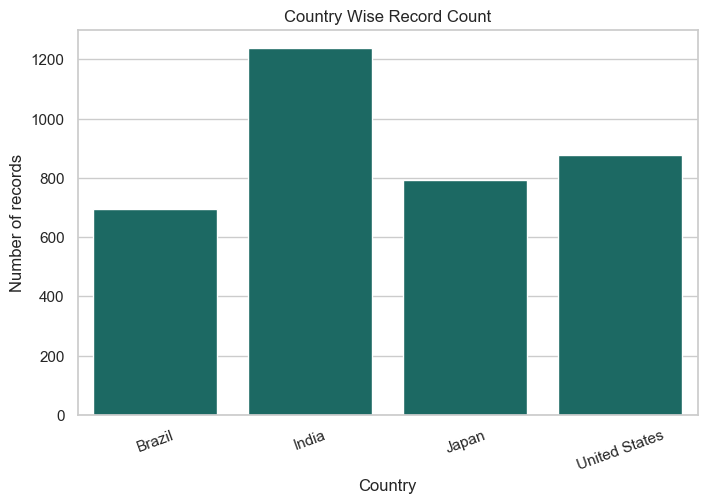

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='country', data=df_clean, color='#0F766E')
plt.title('Country Wise Record Count')
plt.xlabel('Country')
plt.ylabel('Number of records')
plt.xticks(rotation=20)
plt.show()

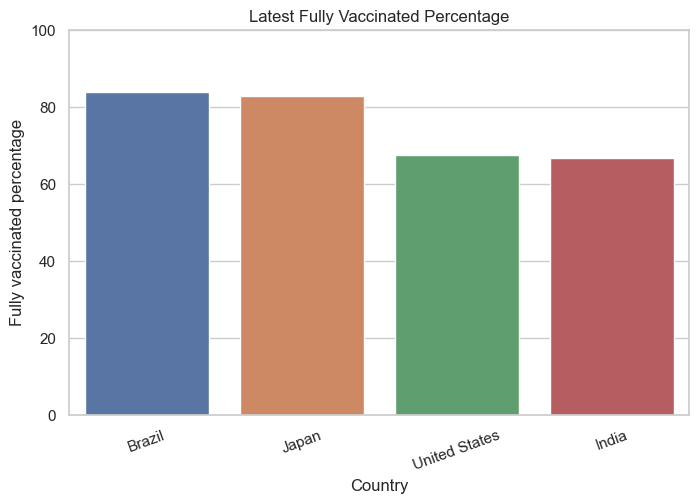

In [15]:
latest = df_clean.groupby('country').tail(1).sort_values('vaccinated_pct', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=latest, x='country', y='vaccinated_pct', hue='country', legend=False)
plt.title('Latest Fully Vaccinated Percentage')
plt.xlabel('Country')
plt.ylabel('Fully vaccinated percentage')
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.show()

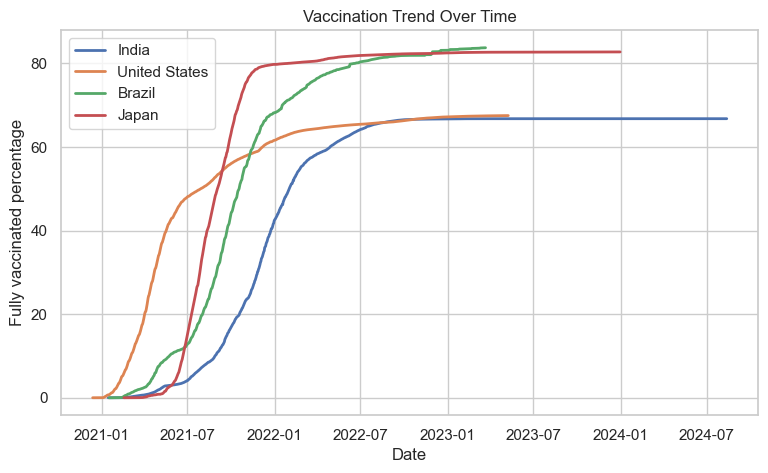

In [16]:
plt.figure(figsize=(9, 5))
for country in countries:
    part = df_clean[df_clean['country'] == country]
    plt.plot(part['date'], part['vaccinated_pct'], label=country, linewidth=2)

plt.title('Vaccination Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Fully vaccinated percentage')
plt.legend()
plt.show()

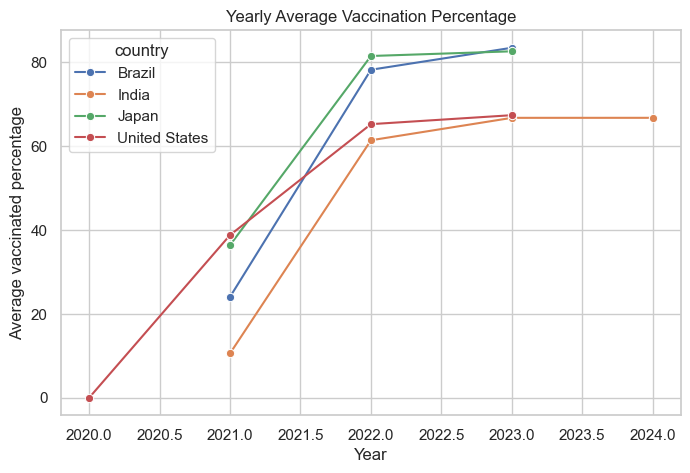

In [17]:
yearly_avg = df_clean.groupby(['country', 'year'])['vaccinated_pct'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_avg, x='year', y='vaccinated_pct', hue='country', marker='o')
plt.title('Yearly Average Vaccination Percentage')
plt.xlabel('Year')
plt.ylabel('Average vaccinated percentage')
plt.show()

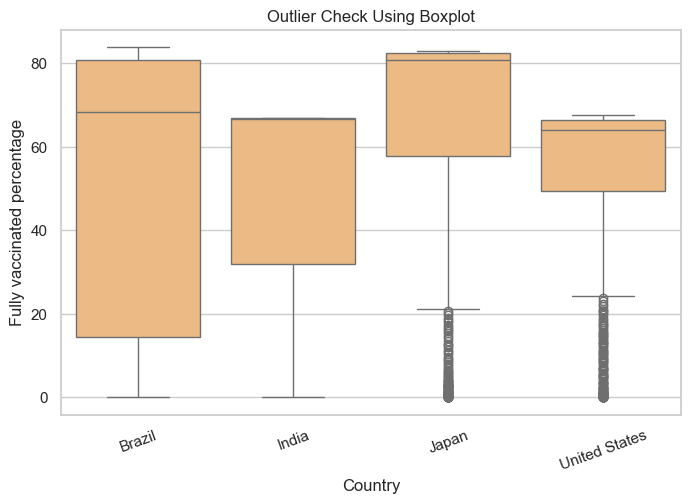

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='country', y='vaccinated_pct', color='#FDBA74')
plt.title('Outlier Check Using Boxplot')
plt.xlabel('Country')
plt.ylabel('Fully vaccinated percentage')
plt.xticks(rotation=20)
plt.show()

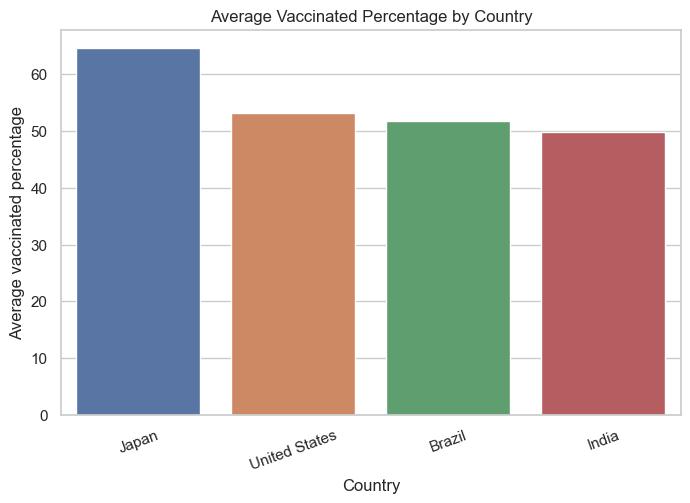

In [19]:
country_average = df_clean.groupby('country')['vaccinated_pct'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=country_average, x='country', y='vaccinated_pct', hue='country', legend=False)
plt.title('Average Vaccinated Percentage by Country')
plt.xlabel('Country')
plt.ylabel('Average vaccinated percentage')
plt.xticks(rotation=20)
plt.show()

In [20]:
latest[['country', 'date', 'vaccinated_pct']]

,country,date,vaccinated_pct
10577,Brazil,2023-03-22,83.76549
38603,Japan,2023-12-31,82.76578
72364,United States,2023-05-09,67.52983
33496,India,2024-08-12,66.78652


In [21]:
df_scaled = df_clean.copy()
df_scaled['vaccinated_scaled'] = df_scaled['vaccinated_pct'] / 100

scaled_latest = df_scaled.groupby('country').tail(1).sort_values('vaccinated_pct', ascending=False)
scaled_latest[['country', 'date', 'vaccinated_pct', 'vaccinated_scaled']]

,country,date,vaccinated_pct,vaccinated_scaled
10577,Brazil,2023-03-22,83.76549,0.837655
38603,Japan,2023-12-31,82.76578,0.827658
72364,United States,2023-05-09,67.52983,0.675298
33496,India,2024-08-12,66.78652,0.667865


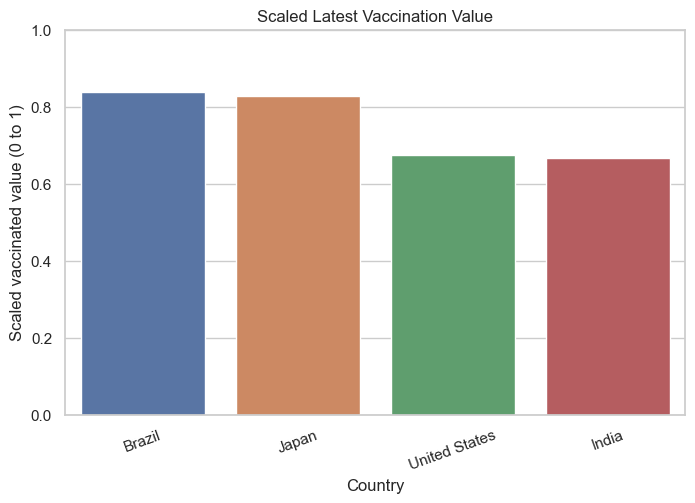

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=scaled_latest, x='country', y='vaccinated_scaled', hue='country', legend=False)
plt.title('Scaled Latest Vaccination Value')
plt.xlabel('Country')
plt.ylabel('Scaled vaccinated value (0 to 1)')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [23]:
df_encoded = df_scaled.copy()
encoded_values, unique_countries = pd.factorize(df_encoded['country'])
df_encoded['country_encoded'] = encoded_values

encoding_table = pd.DataFrame({
    'country': unique_countries,
    'country_encoded': range(len(unique_countries))
})

display(encoding_table)

df_encoded = pd.get_dummies(df_encoded, columns=['country'], drop_first=True)
df_encoded.groupby('country_encoded').tail(1)[['date', 'vaccinated_pct', 'vaccinated_scaled', 'country_encoded']]

,country,country_encoded
0,Brazil,0
1,India,1
2,Japan,2
3,United States,3


,date,vaccinated_pct,vaccinated_scaled,country_encoded
10577,2023-03-22,83.76549,0.837655,0
33496,2024-08-12,66.78652,0.667865,1
38603,2023-12-31,82.76578,0.827658,2
72364,2023-05-09,67.52983,0.675298,3


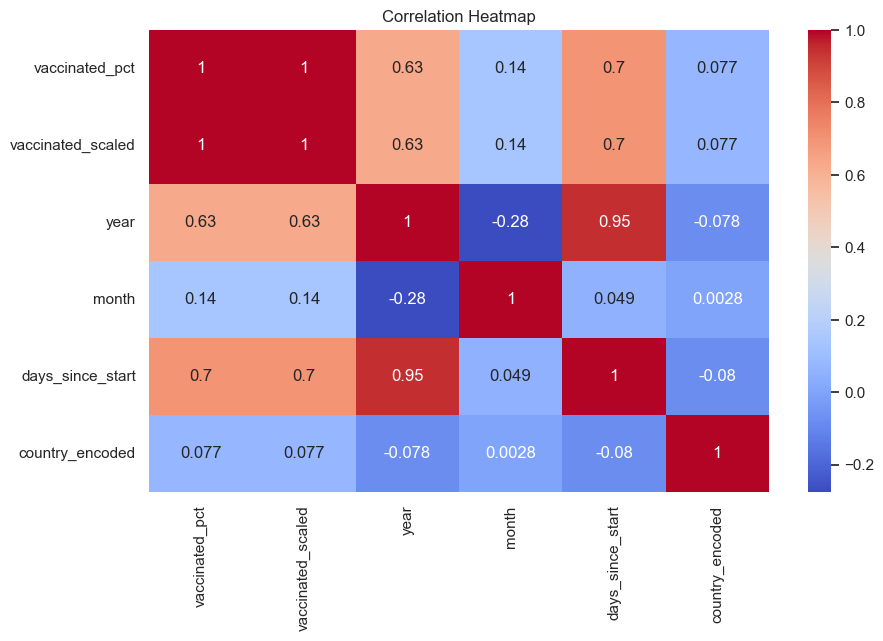

In [24]:
plt.figure(figsize=(10, 6))

corr_cols = ['vaccinated_pct', 'vaccinated_scaled', 'year', 'month', 'days_since_start', 'country_encoded']
corr_matrix = df_encoded[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
print('COVID-19 Vaccination EDA Insights')
print('Highest latest vaccination percentage:')
print(latest.iloc[0][['country', 'date', 'vaccinated_pct']])

print('\nLowest latest vaccination percentage:')
print(latest.iloc[-1][['country', 'date', 'vaccinated_pct']])

print('\nAverage Vaccinated Percentage by Country:')
print(df_clean.groupby('country')['vaccinated_pct'].mean().sort_values(ascending=False))

print('\nCompleted Processing:')
print('Missing value check, duplicate check, cleaning, transformation, encoding, scaling, and visualization were completed.')

COVID-19 Vaccination EDA Insights
Highest latest vaccination percentage:
country                        Brazil
date              2023-03-22 00:00:00
vaccinated_pct               83.76549
Name: 10577, dtype: object

Lowest latest vaccination percentage:
country                         India
date              2024-08-12 00:00:00
vaccinated_pct               66.78652
Name: 33496, dtype: object

Average Vaccinated Percentage by Country:
country
Japan            64.611832
United States    53.176429
Brazil           51.769130
India            49.820410
Name: vaccinated_pct, dtype: float64

Completed Processing:
Missing value check, duplicate check, cleaning, transformation, encoding, scaling, and visualization were completed.
